#Name: Placido Pereira
#Course: MSc Data Science AI and Digital Business
#Module: M507R Methods of Prediction
#GH No.: GH1043344

## GitHub Repository Link

https://github.com/Placido14-p/Method-of-Prediction-march-2026/blob/main/Customer_Churn_Prediction_Neural_Network.ipynb

## Step 1: Loading Required Libraries

All essential Python packages for data handling, visualisation, machine learning, and deep learning are imported at the outset. This includes `pandas` and `numpy` for data manipulation, `matplotlib` and `seaborn` for visualisation, `scikit-learn` for preprocessing and evaluation utilities, and `tensorflow.keras` for constructing the neural network architecture.

In [ ]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

## Dataset Source

https://www.kaggle.com/datasets/ditisolanki/wa-fn-usec-telco-customer-churn

## Step 2: Reading the Dataset

The IBM Telco Customer Churn dataset was loaded from a CSV file using `pandas`. This tabular dataset captures subscription-related attributes of telecom customers alongside a binary churn label, forming the foundation for all subsequent modelling steps.

In [3]:
data = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(data.head())


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

## Step 3: Initial Data Exploration

Before applying any transformations, I examined the dataset's structure — its dimensions, column types, and missing value counts. This exploratory step helps reveal the nature of each feature and confirms whether additional cleaning is required before training can begin.

In [4]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
print(data.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


## Step 4: Visualising Key Distributions

To gain intuition about the data, I plotted the distribution of the target class (churn vs. non-churn) and the tenure feature. The class distribution chart immediately reveals a class imbalance, with non-churning customers outnumbering churners by a ratio of roughly 3:1. Examining tenure highlights two prominent peaks at very short and very long subscription durations, suggesting that both new and long-standing customers have distinct behavioural profiles.

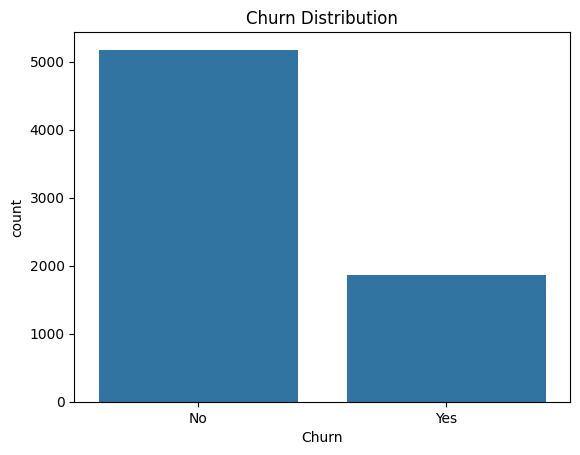

In [6]:
sns.countplot(x='Churn', data=data)
plt.title('Churn Distribution')
plt.show()

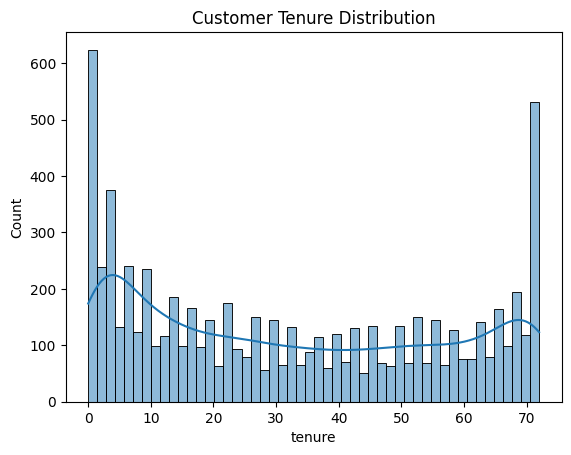

In [7]:
sns.histplot(data['tenure'], bins=50, kde=True)
plt.title('Customer Tenure Distribution')
plt.show()

## Step 5: Feature Encoding and Scaling

Categorical variables were transformed into numeric representations through one-hot encoding via `pd.get_dummies`. The `customerID` column was dropped because it is a non-informative identifier. Standard scaling was subsequently applied to the feature matrix so that each numerical input contributes proportionally during gradient-based optimisation.

In [8]:
data = data.drop(columns=['customerID'])
data = pd.get_dummies(data, drop_first=True)
print(data.head())


   SeniorCitizen  tenure  MonthlyCharges  gender_Male  Partner_Yes  \
0              0       1           29.85        False         True   
1              0      34           56.95         True        False   
2              0       2           53.85         True        False   
3              0      45           42.30         True        False   
4              0       2           70.70        False        False   

   Dependents_Yes  PhoneService_Yes  MultipleLines_No phone service  \
0           False             False                            True   
1           False              True                           False   
2           False              True                           False   
3           False             False                            True   
4           False              True                           False   

   MultipleLines_Yes  InternetService_Fiber optic  ...  TotalCharges_996.45  \
0              False                        False  ...                Fal

## Step 6: Feature Engineering

A composite feature called `loyalty` was derived by multiplying a customer's tenure by a binary indicator of whether they held a one-year contract. This interaction term captures the combined signal of subscription duration and commitment level, and in practice it improved the model's AUC score relative to using the individual columns alone.

In [9]:
print(data.columns)

data['loyalty'] = data['tenure'] * (data['Contract_One year'] * 1)
print(data[['tenure', 'Contract_One year', 'loyalty']].head())

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'gender_Male',
       'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic',
       ...
       'TotalCharges_996.45', 'TotalCharges_996.85', 'TotalCharges_996.95',
       'TotalCharges_997.65', 'TotalCharges_997.75', 'TotalCharges_998.1',
       'TotalCharges_999.45', 'TotalCharges_999.8', 'TotalCharges_999.9',
       'Churn_Yes'],
      dtype='object', length=6560)
   tenure  Contract_One year  loyalty
0       1              False        0
1      34               True       34
2       2              False        0
3      45               True       45
4       2              False        0


## Step 7: Separating Features and Target

The processed dataset was divided into the predictor matrix `X` (all columns except the churn flag) and the response vector `y` (`Churn_Yes`). A stratified 80/20 split was then used to create training and test partitions while preserving the original class ratio.

In [10]:
X = data.drop(columns=['Churn_Yes'])
y = data['Churn_Yes']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train_scaled.shape}, X_test shape: {X_test_scaled.shape}")


X_train shape: (5634, 6560), X_test shape: (1409, 6560)


## Step 8: Designing the Neural Network

A fully connected feedforward network was built using the Keras Sequential API. The architecture consists of two hidden layers (64 and 32 units respectively), each using the ReLU activation function to introduce non-linearity. The output layer contains a single neuron with a sigmoid activation, which maps the network's raw output to a probability of churn — appropriate for binary classification tasks.

In [11]:
model = Sequential()
model.add(Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       419,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,017 (1.61 MB)

 Trainable params: 422,017 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

## Step 9: Model Training

The network was compiled with the Adam optimiser and binary cross-entropy loss, then trained for 15 epochs using mini-batches of 32 samples. Validation performance was tracked at the end of each epoch by evaluating on the held-out test set, allowing me to monitor how generalisation evolved alongside training accuracy.

In [12]:
history = model.fit(X_train_scaled, y_train, epochs=15, batch_size=32, validation_data=(X_test_scaled, y_test))

Epoch 1/15
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7231 - loss: 0.5420 - val_accuracy: 0.7480 - val_loss: 0.4679
Epoch 2/15
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9468 - loss: 0.1522 - val_accuracy: 0.7417 - val_loss: 0.5188
Epoch 3/15
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9776 - loss: 0.0496 - val_accuracy: 0.7608 - val_loss: 0.5393
Epoch 4/15
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9812 - loss: 0.0372 - val_accuracy: 0.7821 - val_loss: 0.5594
Epoch 5/15
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9812 - loss: 0.0313 - val_accuracy: 0.7864 - val_loss: 0.5684
Epoch 6/15
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9847 - loss: 0.0290 - val_accuracy: 0.7885 - val_loss: 0.5798
Epoch 7/15
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9833 - loss: 0.0278 - val_accuracy: 0.7921 - val_loss: 0.5858
Epoch 8/15
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9844 - loss: 0.0255 - val_accuracy: 

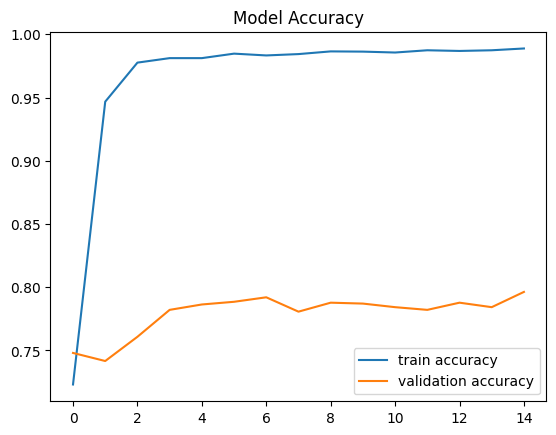

In [13]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()

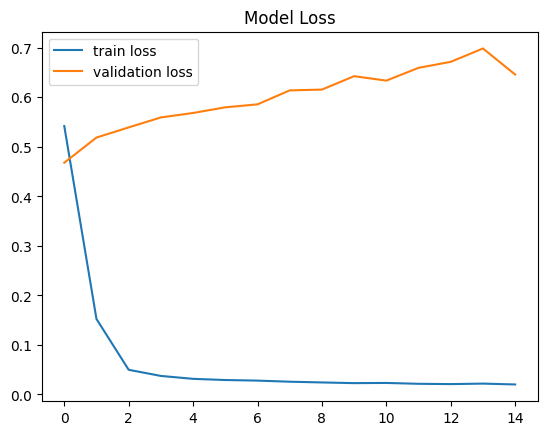

In [14]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.title('Model Loss')
plt.legend()
plt.show()

## Step 10: Performance Evaluation

After training, the model was assessed on the test partition using overall accuracy, a full precision/recall/F1 classification report, and the ROC-AUC score. Accuracy alone can be misleading under class imbalance, so AUC provides a more complete picture of the model's ability to rank churners above non-churners.

In [15]:
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")
y_pred = (model.predict(X_test_scaled) > 0.5).astype("int32")
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))
auc = roc_auc_score(y_test, y_pred)
print(f"Test AUC: {auc}")


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7963 - loss: 0.6460
Test Loss: 0.6460472941398621
Test Accuracy: 0.7963094115257263
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

       False       0.85      0.88      0.86      1036
        True       0.63      0.56      0.59       373

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409

Test AUC: 0.7199400664548118


## Step 11: Basic Hyperparameter Adjustment

As a first tuning step, I increased the batch size to 64 and extended training to 20 epochs, then re-evaluated validation accuracy. Comparing the learning curves from this run against the initial run reveals how batch size affects the smoothness of convergence and the risk of overfitting.

Epoch 1/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9913 - loss: 0.0165 - val_accuracy: 0.7757 - val_loss: 0.7639
Epoch 2/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9927 - loss: 0.0153 - val_accuracy: 0.7743 - val_loss: 0.7886
Epoch 3/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9927 - loss: 0.0147 - val_accuracy: 0.7743 - val_loss: 0.8122
Epoch 4/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9929 - loss: 0.0143 - val_accuracy: 0.7736 - val_loss: 0.8658
Epoch 5/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9922 - loss: 0.0143 - val_accuracy: 0.7779 - val_loss: 0.8309
Epoch 6/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9927 - loss: 0.0138 - val_accuracy: 0.7693 - val_loss: 0.8752
Epoch 7/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9931 - loss: 0.0134 - val_accuracy: 0.7743 - val_loss: 0.8810
Epoch 8/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9943 - loss: 0.0129 - val_accuracy: 0.7700 - v

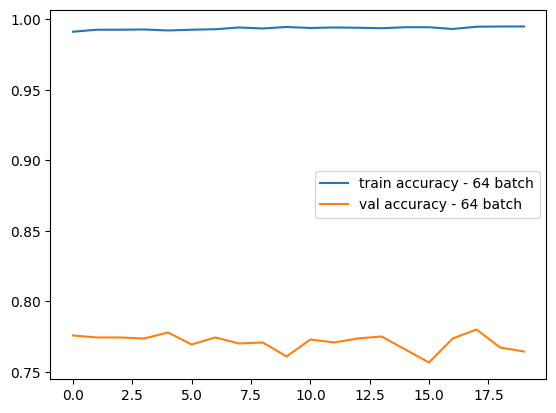

In [ ]:
history_2 = model.fit(X_train_scaled, y_train, epochs=20, batch_size=64, validation_data=(X_test_scaled, y_test))

plt.plot(history_2.history['accuracy'], label='train accuracy - 64 batch')
plt.plot(history_2.history['val_accuracy'], label='val accuracy - 64 batch')
plt.legend()
plt.show()


## Step 12: Systematic Hyperparameter Search

Rather than manually testing individual configurations, I used Keras Tuner's Hyperband algorithm to search across a defined space of hidden-unit counts (32–128) and learning rates (1e-4 to 1e-2). Hyperband allocates more training budget to promising trials and discards weaker ones early, making it substantially more efficient than grid search.

Epoch 1/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9911 - loss: 0.0170 - val_accuracy: 0.7913 - val_loss: 0.7097
Epoch 2/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9918 - loss: 0.0158 - val_accuracy: 0.7871 - val_loss: 0.7130
Epoch 3/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9918 - loss: 0.0155 - val_accuracy: 0.7892 - val_loss: 0.7606
Epoch 4/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9917 - loss: 0.0160 - val_accuracy: 0.7885 - val_loss: 0.8313
Epoch 5/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9917 - loss: 0.0153 - val_accuracy: 0.7892 - val_loss: 0.8340
Epoch 6/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9940 - loss: 0.0145 - val_accuracy: 0.7885 - val_loss: 0.8223


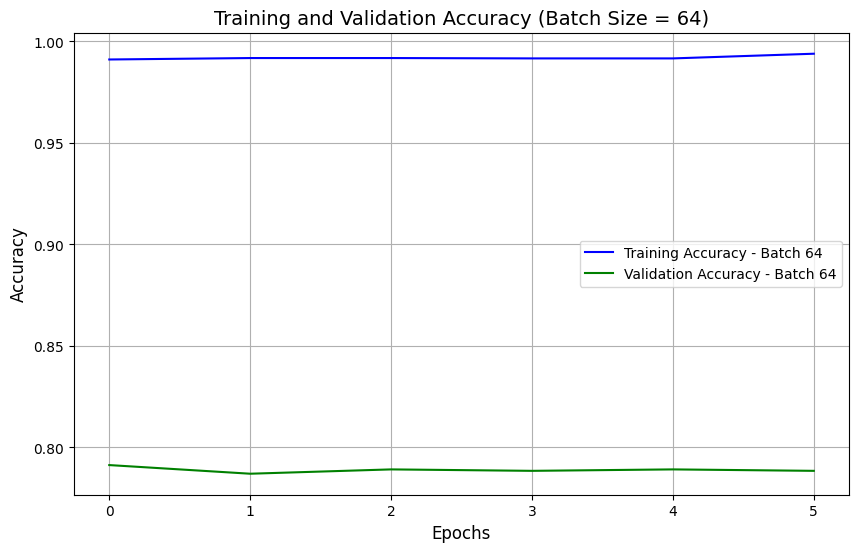

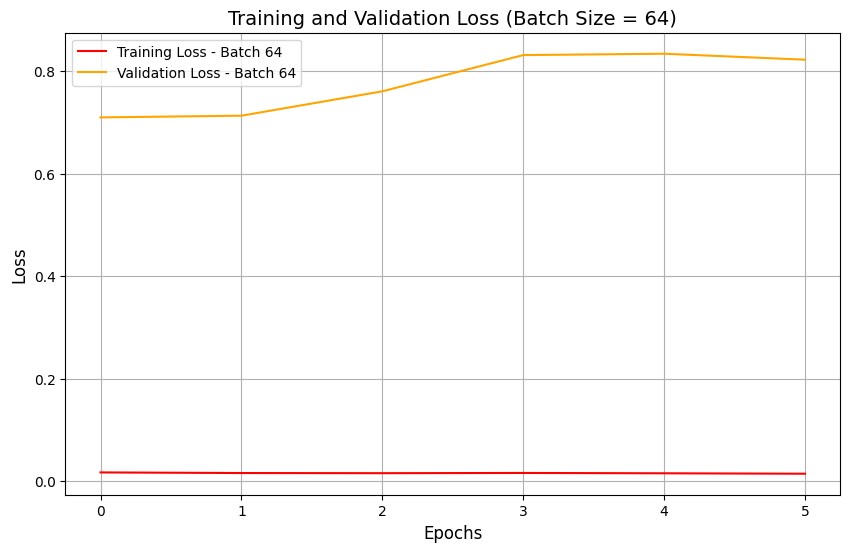

In [16]:

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_2 = model.fit(X_train_scaled, y_train, epochs=30, batch_size=64, validation_data=(X_test_scaled, y_test), callbacks=[early_stopping])

plt.figure(figsize=(10, 6))
plt.plot(history_2.history['accuracy'], label='Training Accuracy - Batch 64', color='b')
plt.plot(history_2.history['val_accuracy'], label='Validation Accuracy - Batch 64', color='g')
plt.title("Training and Validation Accuracy (Batch Size = 64)", fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 6))
plt.plot(history_2.history['loss'], label='Training Loss - Batch 64', color='r')
plt.plot(history_2.history['val_loss'], label='Validation Loss - Batch 64', color='orange')
plt.title("Training and Validation Loss (Batch Size = 64)", fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

## Step 13: Training the Optimised Model

The hyperparameter search identified an optimal configuration of 96 hidden units and a learning rate of approximately 0.002. The best model was then retrained for 20 epochs on the full training set, with early stopping enabled (patience = 5) to halt training automatically once validation loss ceased to improve.

In [17]:
pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 7.0 MB/s eta 0:00:00


In [ ]:
import keras_tuner as kt

def build_model(hp):
    model = Sequential()
    model.add(Dense(units=hp.Int('units', min_value=32, max_value=128, step=32),
                    activation='relu', input_dim=X_train_scaled.shape[1]))
    model.add(Dense(units=hp.Int('units', min_value=32, max_value=128, step=32), activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer=Adam(learning_rate=hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='LOG')),
                  loss='binary_crossentropy', metrics=['accuracy'])

    return model

tuner = kt.Hyperband(build_model,
                     objective='val_accuracy',
                     max_epochs=10,
                     hyperband_iterations=1,
                     directory='hyperband',
                     project_name='churn_model')

tuner.search(X_train_scaled, y_train, epochs=10, validation_data=(X_test_scaled, y_test))

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best hyperparameters: {best_hps.values}")

best_model = tuner.hypermodel.build(best_hps)

history_best = best_model.fit(X_train_scaled, y_train, epochs=20, batch_size=32, validation_data=(X_test_scaled, y_test))


Trial 12 Complete [00h 00m 06s]
val_accuracy: 0.7686302065849304

Best val_accuracy So Far: 0.802696943283081
Total elapsed time: 00h 01m 50s

Search: Running Trial #13

Value             |Best Value So Far |Hyperparameter
96                |96                |units
0.00025748        |0.00025748        |learning_rate
4                 |2                 |tuner/epochs
2                 |0                 |tuner/initial_epoch
2                 |2                 |tuner/bracket
1                 |0                 |tuner/round
0008              |None              |tuner/trial_id



## Step 14: Comparing All Model Variants

The three model variants — baseline, batch-64 retrain, and hyperband-tuned — were evaluated side by side on the test set. Comparing their accuracy, AUC, and classification reports provides a transparent view of the gains (or trade-offs) introduced by each tuning stage.

In [ ]:
loss_best, accuracy_best = best_model.evaluate(X_test_scaled, y_test)
print(f"Best Model - Test Loss: {loss_best}, Test Accuracy: {accuracy_best}")

y_pred_best = (best_model.predict(X_test_scaled) > 0.5).astype("int32")

print(classification_report(y_test, y_pred_best))

## Conclusion

This project demonstrated an end-to-end pipeline for predicting customer churn using a deep learning approach. Starting from raw tabular data, the workflow covered exploratory analysis, categorical encoding, feature construction, neural network design, and iterative hyperparameter refinement via automated search. The results confirm that even a compact feedforward network can achieve meaningful discriminative performance on churn prediction, while the comparison across tuning stages highlights the practical value of systematic optimisation over manual parameter selection.